# Preguntas del taller 4

1. Crear una función que permita determinar las intensidades de los Píxeles vecinos a un determinado Píxel de coordenadas definidas por el usuario. Los argumentos de entrada son la imagen y las coordenadas, y la salida una matriz con las intensidades de
los 8‐vecinos del Píxel.

2. Probar el algoritmo con una imagen.

3. Probar el algoritmo con una imagen en escala de grises y con las coordenadas (82,29), (68,27), (112,89), (114,89) y (27,130) de la imagen binaria «piano.bmp».

4. Ejecutar la ecualización local del histograma de una imagen. Debe mostrar la imagen original, la imagen ecualizada y los histogramas de las imágenes.

5. Crear un programa basado en ciclos que permita adelantar la ecualización local del histograma de una imagen. Utilice la imagen “Piano.pgm” con el fin de observar los efectos causados por la ecualización (se recomienda ajustar Amin = 0.5 y Amax = 2.5).

6. Crear una función basada en ciclos, que permita realizar las principales operaciones lógicas entre dos imágenes.
Verificar el algoritmo con las imágenes «CuadroBinGrande.pgm» y «CuadroBinChico.pgm».

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("resultados", exist_ok=True)

## Punto 1
Crear una función que permita determinar las intensidades de los Píxeles vecinos a un determinado Píxel de coordenadas definidas por el usuario. Los argumentos de entrada son la imagen y las coordenadas, y la salida una matriz con las intensidades de
los 8‐vecinos del Píxel.

In [2]:
"""
x representa la coordenada horizontal o columna.
y representa la coordenada vertical o fila.

En NumPy y OpenCV, una imagen se accede usando:
imagen[y, x]

Es decir, primero se indica la fila y después la columna.
"""

def obtener_8_vecinos(imagen, x, y):
    filas, columnas = imagen.shape[:2]

    # Comprobar bordes para evitar acceder a píxeles fuera de la imagen
    if x <= 0 or x >= columnas - 1:
        raise ValueError("La coordenada x está fuera de los límites de la imagen.")
    if y <= 0 or y >= filas - 1:
        raise ValueError("La coordenada y está fuera de los límites de la imagen.")

    # Obtener los 8 vecinos
    vecinos = np.array([
        [
            imagen[y - 1, x - 1],  # Arriba izquierda
            imagen[y - 1, x],      # Arriba
            imagen[y - 1, x + 1]   # arriba derecha
        ],  
        [
            imagen[y, x - 1],      # Izquierda
            -1,         # Centro
            imagen[y, x + 1]      # Derecha
        ],
        [
            imagen[y + 1, x - 1],  # Abajo izquierda
            imagen[y + 1, x],      # Abajo
            imagen[y + 1, x + 1]   # Abajo derecha
        ]
    ],dtype=int)
    return vecinos

def obtener_8_vecinos_ciclos(imagen, x, y):
    filas, columnas = imagen.shape[:2]

    # Comprobar bordes para evitar acceder a píxeles fuera de la imagen
    if x <= 0 or x >= columnas - 1:
        raise ValueError("La coordenada x está fuera de los límites de la imagen.")
    if y <= 0 or y >= filas - 1:
        raise ValueError("La coordenada y está fuera de los límites de la imagen.")

    vecinos = np.full((3, 3), -1, dtype=int)  # Inicializar con -1 todos los valores

    #Recorrer las posiciones relativas de los vecinos
    for dy in range(-1, 2): # -1, 0, 1
        for dx in range(-1, 2): # -1, 0, 1
            if dy == 0 and dx == 0: # Centro, se deja como -1
                continue
            vecinos[dy + 1, dx + 1] = imagen[y + dy, x + dx]

    return vecinos

### Conclusiones del punto 1 – Vecindad de 8 píxeles

En este punto se implementó una función para obtener las intensidades de los 8 vecinos que rodean a un píxel de coordenadas \((x,y)\).

La vecindad de 8 considera los píxeles ubicados arriba, abajo, izquierda, derecha y en las cuatro diagonales del píxel central. La información se organizó en una matriz de \(3\times3\), dejando el centro con el valor \(-1\) para indicar que el píxel seleccionado no pertenece al conjunto de sus propios vecinos.

También fue importante diferenciar la forma de expresar las coordenadas y la forma de acceder a una imagen en NumPy/OpenCV. Aunque las coordenadas se expresan como:

\[
(x,y)
\]

donde \(x\) representa la posición horizontal y \(y\) la vertical, en NumPy se accede primero a la fila y luego a la columna:

\[
\texttt{imagen[y,x]}
\]

La función también verifica que el píxel seleccionado no se encuentre en el borde de la imagen, ya que en estas posiciones no existen los ocho vecinos completos.

En conclusión, la función desarrollada permite obtener la información espacial inmediata alrededor de cualquier píxel interno de una imagen. Este concepto es fundamental en procesamiento digital de imágenes, debido a que muchas técnicas como filtrado, detección de bordes, análisis de textura y operaciones locales dependen de la relación entre un píxel y su vecindad.

2. Probar el algoritmo con una imagen.

Píxel central: 128
8 vecinos:
[[157 124 127]
 [167  -1 134]
 [169 126 135]]


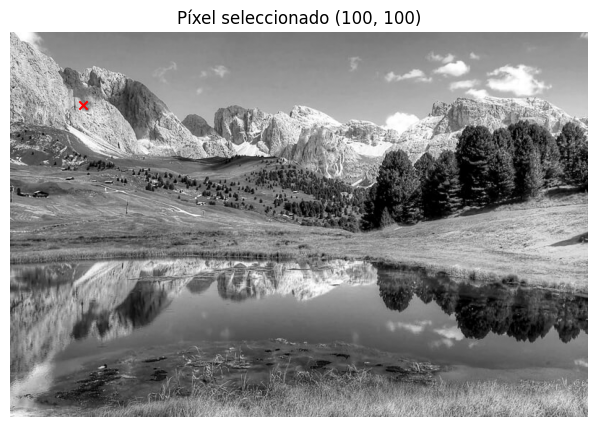

In [3]:
imagen = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)

if imagen is None:
    raise FileNotFoundError("No se encontró la imagen en images/paisaje.png")

x, y = 100, 100

vecinos = obtener_8_vecinos(imagen, x, y)

print("Píxel central:", imagen[y, x])
print("8 vecinos:")
print(vecinos)
#Visualizacion punto
plt.figure(figsize=(8, 5))
plt.imshow(imagen, cmap="gray")

plt.scatter(
    x,
    y,
    marker="x",
    color="red"
)

plt.title(
    f"Píxel seleccionado ({x}, {y})"
)

plt.axis("off")
plt.savefig("resultados/punto1.png", bbox_inches="tight")
plt.show()


### Conclusiones del punto 2 – Prueba del algoritmo con una imagen

El algoritmo de vecindad se verificó utilizando una imagen en escala de grises y seleccionando el píxel ubicado en las coordenadas:

\[
(x,y)=(100,100)
\]

El píxel central presentó una intensidad de 128 y la matriz obtenida para sus ocho vecinos fue:

\[
\begin{bmatrix}
157 & 124 & 127\\
167 & -1 & 134\\
169 & 126 & 135
\end{bmatrix}
\]

La representación gráfica permitió comprobar que la coordenada \((100,100)\) se localiza tomando como origen la esquina superior izquierda de la imagen: \(x\) aumenta hacia la derecha y \(y\) hacia abajo.

Los valores obtenidos muestran que los píxeles vecinos pueden tener intensidades similares o diferentes al píxel central. Estas variaciones locales contienen información importante sobre la estructura de la imagen.

En conclusión, la prueba confirmó que la función recorre correctamente la imagen y recupera las intensidades correspondientes a las ocho posiciones que rodean al píxel seleccionado.

3. Probar el algoritmo con una imagen en escala de grises y con las coordenadas (82,29), (68,27), (112,89), (114,89) y (27,130) de la imagen binaria «piano.bmp».

In [4]:
coordenadas = [
    (82,29),
    (68,27),
    (112,89),
    (114,89),
    (27,130)
]

imagen_piano = cv2.imread("images/PIANO.bmp", cv2.IMREAD_GRAYSCALE)

for x, y in coordenadas:
    vecinos = obtener_8_vecinos(imagen_piano, x, y)
    print(f"Píxel central(coordenadas) ({x}, {y}):", imagen_piano[y, x])
    print("8 vecinos:")
    print(vecinos)
    print()  # Línea en blanco para separar resultados

Píxel central(coordenadas) (82, 29): 63
8 vecinos:
[[ 53  65 103]
 [ 50  -1 105]
 [ 50  68 116]]

Píxel central(coordenadas) (68, 27): 63
8 vecinos:
[[62 62 61]
 [62 -1 59]
 [61 64 58]]

Píxel central(coordenadas) (112, 89): 59
8 vecinos:
[[66 61 64]
 [66 -1 63]
 [62 58 63]]

Píxel central(coordenadas) (114, 89): 86
8 vecinos:
[[ 64  91 103]
 [ 63  -1 106]
 [ 63  73  93]]

Píxel central(coordenadas) (27, 130): 93
8 vecinos:
[[ 90 102  90]
 [ 97  -1  82]
 [102  87  81]]



4. Ejecutar la ecualización local del histograma de una imagen. Debe mostrar la imagen original, la imagen ecualizada y los histogramas de las imágenes.


In [5]:
imagen = cv2.imread(
    "images/PIANO.pgm",
    cv2.IMREAD_GRAYSCALE
)

if imagen is None:
    raise FileNotFoundError("No se pudo cargar PIANO.pgm")

imagen_float = imagen.astype(np.float32)

# Define tamaño de vecindad, por ejemplo si es 3, al pixel se analiza usando el 3x3, osea sus 8 vecinos
tam_vecindad = 3

# MEDIA LOCAL
#Calcular media de cada ventana de 3x3 que equivale al xpromedio(i,j)
"""
imagen original       media local
--------------        -----------
pixel (0,0)   --->    promedio alrededor de (0,0)
pixel (0,1)   --->    promedio alrededor de (0,1)
pixel (0,2)   --->    promedio alrededor de (0,2)

Media_local no es un solo número. Es otra matriz del mismo tamaño que la imagen:
media_local[y, x] = promedio de los 8 vecinos alrededor del pixel (x,y)
"""

media_local = cv2.blur(imagen_float, (tam_vecindad, tam_vecindad))

# Desviacion estandar local
# para ello se calcula la media de los cuadrados y se aplica la formula de desviacion estandar

# Media local de x^2
media_cuadrados=cv2.blur(imagen_float**2, (tam_vecindad, tam_vecindad))

# Varianza local
varianza_local=(media_cuadrados-media_local**2)

# Desviacion estandar local
desviacion_estandar_local=np.sqrt(np.maximum(varianza_local, 0))  # Evitar valores negativos por errores de redondeo

# media global de la imagen
media_global = np.mean(imagen_float)

# Calcular A(i,j)
k= 0.5

epsilon = 1e-6  # Para evitar división por cero en caso de que la desviación estándar local sea cero, esto es cuando todos los pixeles de la ventana son iguales, entonces la desviacion estandar es 0 y se evita la division por 0

# Factor de realce local
A=(k * media_global/(desviacion_estandar_local + epsilon))

# Aplical formula transformacion local
imagen_local = A*( imagen_float - media_local) + media_local

#limitacion a [0,255]
imagen_local = np.clip( imagen_local, 0, 255).astype(np.uint8)

hist_original = cv2.calcHist(
    [imagen],
    [0],
    None,
    [256],
    [0, 256]
)

hist_local = cv2.calcHist(
    [imagen_local],
    [0],
    None,
    [256],
    [0, 256]
)



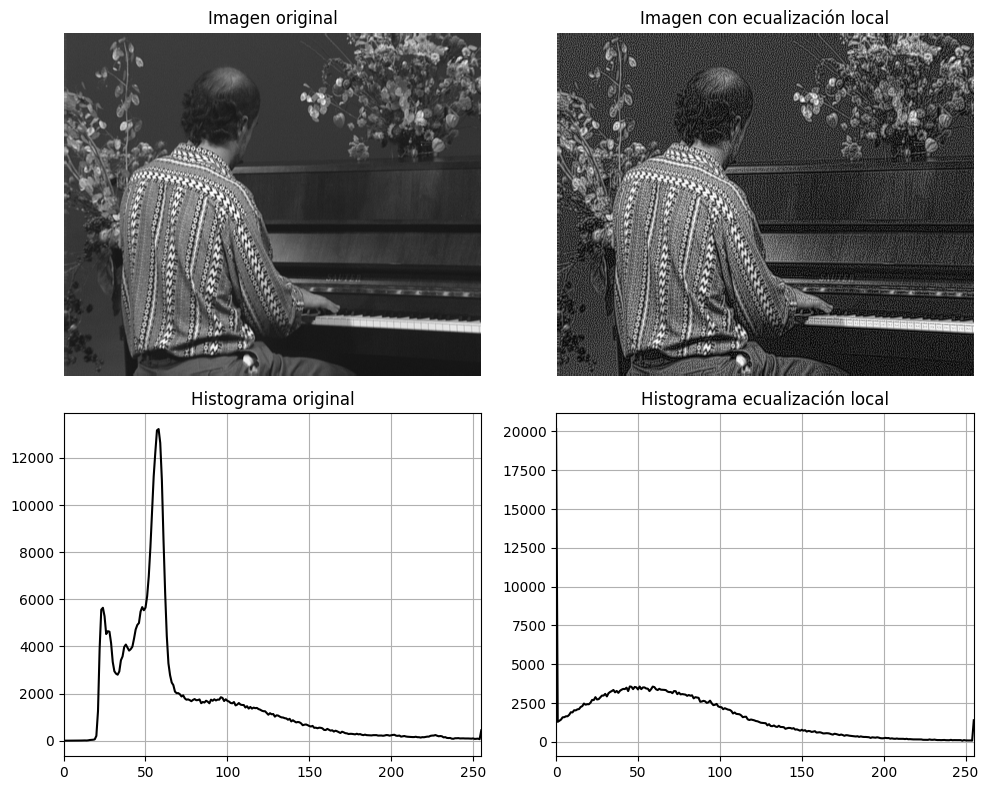

Histograma_original: [0.0000e+00 1.0000e+00 1.0000e+00 0.0000e+00 1.0000e+00 1.0000e+00
 2.0000e+00 3.0000e+00 5.0000e+00 5.0000e+00 5.0000e+00 7.0000e+00
 1.0000e+01 1.1000e+01 8.0000e+00 1.5000e+01 2.9000e+01 3.6000e+01
 4.1000e+01 5.6000e+01 2.0400e+02 1.2560e+03 3.9030e+03 5.5610e+03
 5.6410e+03 5.2820e+03 4.5260e+03 4.6480e+03 4.6260e+03 4.1390e+03
 3.3420e+03 2.9470e+03 2.8460e+03 2.8010e+03 2.9370e+03 3.4150e+03
 3.5760e+03 3.9780e+03 4.0800e+03 3.9510e+03 3.8230e+03 3.8870e+03
 3.9910e+03 4.3330e+03 4.7200e+03 4.9110e+03 4.9960e+03 5.4820e+03
 5.6700e+03 5.5370e+03 5.6460e+03 6.1270e+03 6.9790e+03 8.2120e+03
 9.6970e+03 1.1218e+04 1.2243e+04 1.3173e+04 1.3227e+04 1.2640e+04
 1.1057e+04 8.5090e+03 6.2720e+03 4.4390e+03 3.2840e+03 2.7810e+03
 2.4700e+03 2.3590e+03 2.0830e+03 2.0170e+03 2.0190e+03 1.9690e+03
 1.8770e+03 1.9250e+03 1.7980e+03 1.7390e+03 1.7540e+03 1.7220e+03
 1.6770e+03 1.7310e+03 1.7670e+03 1.7170e+03 1.7250e+03 1.7510e+03
 1.5910e+03 1.6430e+03 1.6210e+03 1.6960e

In [6]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8)
)

axes[0, 0].imshow(
    imagen,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0, 0].set_title(
    "Imagen original"
)

axes[0, 0].axis("off")


axes[0, 1].imshow(
    imagen_local,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0, 1].set_title(
    "Imagen con ecualización local"
)

axes[0, 1].axis("off")


axes[1, 0].plot(
    hist_original,
    color="black"
)

axes[1, 0].set_title(
    "Histograma original"
)

axes[1, 0].set_xlim(0, 255)
axes[1, 0].grid()


axes[1, 1].plot(
    hist_local,
    color="black"
)

axes[1, 1].set_title(
    "Histograma ecualización local"
)

axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid()


plt.tight_layout()

plt.savefig(
    "resultados/ecualizacion_local_pt4.png"
)

plt.show()

print("Histograma_original:", hist_original)
print("Histograma_ecualizacion_local:", hist_local)

### Conclusiones del punto 3 – Análisis de vecindades en `PIANO.bmp`

La función desarrollada se aplicó a la imagen `PIANO.bmp` utilizando las coordenadas:

\[
(82,29),\ (68,27),\ (112,89),\ (114,89),\ (27,130)
\]

En cada caso se obtuvo la intensidad del píxel central y la matriz correspondiente a sus ocho vecinos.

Los resultados permiten observar que la variación de intensidades depende de la región de la imagen analizada. Por ejemplo, en la coordenada \((68,27)\), el píxel central tiene intensidad 63 y sus vecinos presentan valores aproximadamente entre 58 y 64. Esto indica una zona bastante homogénea, ya que las intensidades son muy similares.

En cambio, alrededor de la coordenada \((82,29)\) aparecen valores entre aproximadamente 50 y 116. Esta mayor diferencia entre píxeles indica una región con mayor variación local, que puede corresponder a una transición, borde o zona con mayor detalle dentro de la imagen.

De manera similar, las otras coordenadas presentan distintos niveles de variación entre el píxel central y sus vecinos. Esto demuestra que una vecindad permite caracterizar localmente una región de la imagen sin necesidad de analizarla completamente.

En conclusión, el análisis de los 8 vecinos permite identificar zonas homogéneas y zonas donde existen cambios importantes de intensidad. Esta información constituye la base de técnicas posteriores como detección de bordes, segmentación, filtrado y ecualización local.

## Conclusiones del punto 4 – Ecualización local

En este punto se aplicó una ecualización local a la imagen `PIANO.pgm`. A diferencia de una transformación global, cada píxel se modifica teniendo en cuenta las características de una pequeña región o vecindad alrededor de él.

La transformación utilizada fue:

$$
y(i,j)
=
A(i,j)
\left[
x(i,j)-\bar{x}(i,j)
\right]
+
\bar{x}(i,j)
$$

donde:

- $x(i,j)$ es la intensidad original del píxel.
- $\bar{x}(i,j)$ es la media de intensidades de su vecindad.
- $\sigma(i,j)$ es la desviación estándar local.
- $A(i,j)$ determina cuánto se realza el contraste local.

El factor de realce se calcula mediante:

$$
A(i,j)
=
k\frac{\bar{x}_G}{\sigma(i,j)}
$$

Cuando la desviación estándar local es **pequeña**, los píxeles vecinos tienen intensidades muy parecidas y existe poco contraste en esa zona. En este caso, $A(i,j)$ aumenta y la transformación amplifica las diferencias locales, haciendo visibles detalles que antes eran poco notorios.

Por el contrario, cuando la desviación estándar local es **grande**, ya existen diferencias importantes entre los píxeles vecinos. Por lo tanto, $A(i,j)$ disminuye y el realce aplicado es menor.

En la imagen obtenida se observa un aumento del contraste local, especialmente en texturas como la ropa, el cabello, las plantas y el piano. El histograma también cambia considerablemente y utiliza una mayor parte del rango de intensidades.

Además, aparecen acumulaciones importantes en los valores 0 y 255. Esto ocurre porque algunos valores calculados quedan por debajo de 0 o por encima de 255. Para mantener los valores dentro del rango válido de una imagen de 8 bits, se limitan mediante `np.clip()`:

```python
imagen_ecualizada = np.clip(
    imagen_ecualizada,
    0,
    255
)

5. Crear un programa basado en ciclos que permita adelantar la ecualización local del histograma de una imagen. Utilice la imagen “Piano.pgm” con el fin de observar los efectos causados por la ecualización (se recomienda ajustar Amin = 0.5 y Amax = 2.5).

Ahora se calcula manualmente las medias locales

para obtener las estadísticas locales.
Vamos a calcularlas manualmente.

La idea para cada píxel será:
tomar ventana 3×3
       ↓
calcular media local
       ↓
calcular desviación local
       ↓
calcular A
       ↓
limitar A entre 0.5 y 2.5
       ↓
calcular nuevo píxel

In [7]:
imagen= cv2.imread(
    "images/PIANO.pgm",
    cv2.IMREAD_GRAYSCALE
)

imagen_float = imagen.astype(np.float32)

filas, columnas = imagen.shape[:2]

imagen_local_manual= imagen_float.copy()

media_global = np.mean(imagen_float)

k= 0.5
Amin= 0.5
Amax= 2.5


for fila in range(1, filas - 1): # evitamos los bordes
    for columna in range(1, columnas - 1):
        # Obtener los 8 vecino
        ventana = imagen_float[
            fila - 1:fila + 2, columna - 1:columna + 2
        ]
        media_local = np.mean(ventana)
        desviacion_estandar_local = np.std(ventana)
        if desviacion_estandar_local != 0:
            A = k * media_global / desviacion_estandar_local
        else:
            A = Amax  # Si la desviación estándar local es cero, usamos Amax

        # Limitar A al rango [Amin, Amax]
        A = np.clip(A, Amin, Amax)

        # Aplicamos transformación al pixel central de la ventana
        pixel_original = imagen_float[fila, columna]
        pixel_transformado = A * (pixel_original - media_local) + media_local

        # Limitamos el valor del pixel transformado al rango [0, 255] y lo asignamos a la imagen resultante
        imagen_local_manual[fila, columna] = np.clip(pixel_transformado, 0, 255)

#se ha trabajado en float32,debe trabajar en uint8 guardarla y visualizarla correctamente
imagen_local_manual = imagen_local_manual.astype(np.uint8)

histograma_original = cv2.calcHist(
    [imagen],
    [0],
    None,
    [256],
    [0, 256]
)

histograma_local_manual = cv2.calcHist(
    [imagen_local_manual],
    [0],
    None,
    [256],
    [0, 256]
)

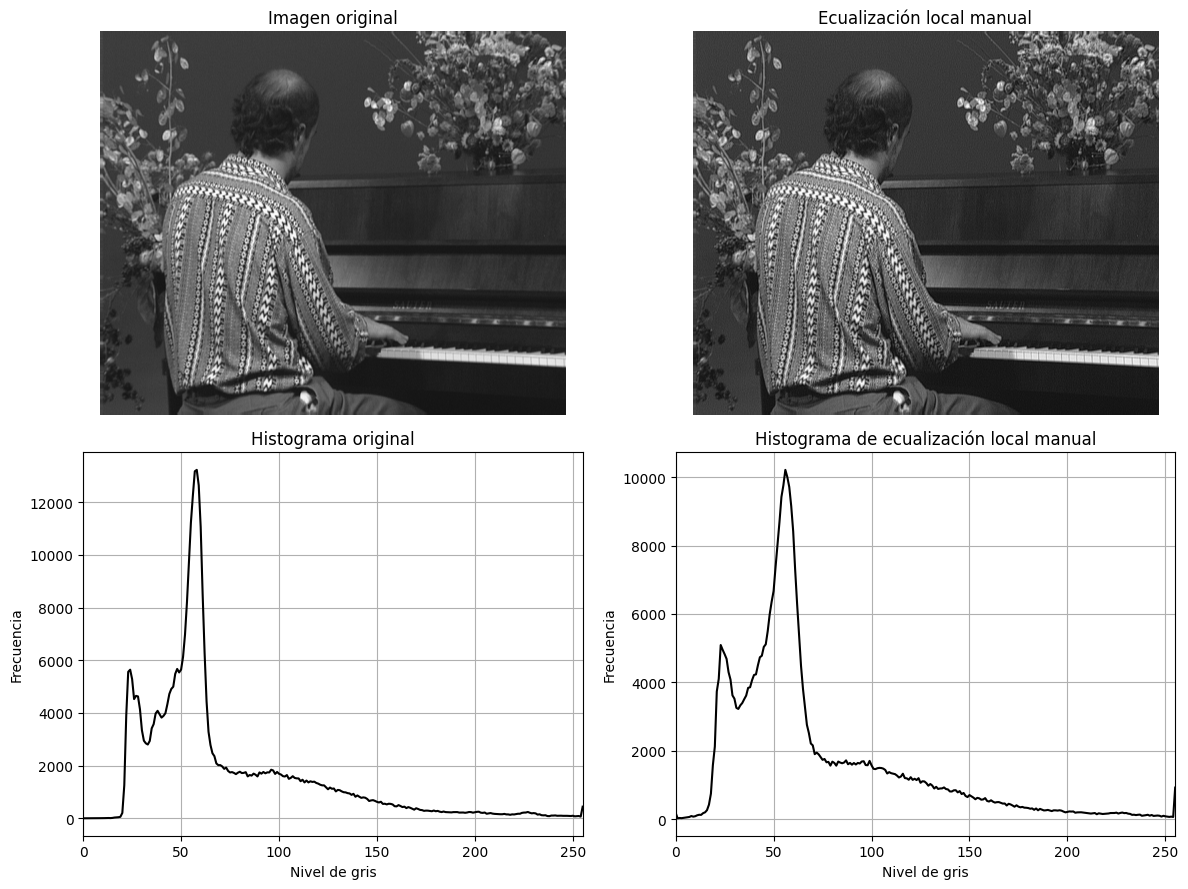

Promedio original: 72.13844742063492
Promedio transformada: 71.68619791666667
Mínimo original: 1
Máximo original: 255
Mínimo transformada: 0
Máximo transformada: 255
Total píxeles original: 403200
Total píxeles transformada: 403200
Histograma original: [0.0000e+00 1.0000e+00 1.0000e+00 0.0000e+00 1.0000e+00 1.0000e+00
 2.0000e+00 3.0000e+00 5.0000e+00 5.0000e+00 5.0000e+00 7.0000e+00
 1.0000e+01 1.1000e+01 8.0000e+00 1.5000e+01 2.9000e+01 3.6000e+01
 4.1000e+01 5.6000e+01 2.0400e+02 1.2560e+03 3.9030e+03 5.5610e+03
 5.6410e+03 5.2820e+03 4.5260e+03 4.6480e+03 4.6260e+03 4.1390e+03
 3.3420e+03 2.9470e+03 2.8460e+03 2.8010e+03 2.9370e+03 3.4150e+03
 3.5760e+03 3.9780e+03 4.0800e+03 3.9510e+03 3.8230e+03 3.8870e+03
 3.9910e+03 4.3330e+03 4.7200e+03 4.9110e+03 4.9960e+03 5.4820e+03
 5.6700e+03 5.5370e+03 5.6460e+03 6.1270e+03 6.9790e+03 8.2120e+03
 9.6970e+03 1.1218e+04 1.2243e+04 1.3173e+04 1.3227e+04 1.2640e+04
 1.1057e+04 8.5090e+03 6.2720e+03 4.4390e+03 3.2840e+03 2.7810e+03
 2.4700e+0

In [8]:


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

# -------------------------
# Imagen original
# -------------------------
axes[0, 0].imshow(
    imagen,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0, 0].set_title(
    "Imagen original"
)

axes[0, 0].axis("off")


# -------------------------
# Imagen ecualizada manual
# -------------------------
axes[0, 1].imshow(
    imagen_local_manual,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0, 1].set_title(
    "Ecualización local manual"
)

axes[0, 1].axis("off")


# -------------------------
# Histograma original
# -------------------------
axes[1, 0].plot(
    histograma_original,
    color="black"
)

axes[1, 0].set_title(
    "Histograma original"
)

axes[1, 0].set_xlabel(
    "Nivel de gris"
)

axes[1, 0].set_ylabel(
    "Frecuencia"
)

axes[1, 0].set_xlim(
    0,
    255
)

axes[1, 0].grid()


# -------------------------
# Histograma transformado
# -------------------------
axes[1, 1].plot(
    histograma_local_manual,
    color="black"
)

axes[1, 1].set_title(
    "Histograma de ecualización local manual"
)

axes[1, 1].set_xlabel(
    "Nivel de gris"
)

axes[1, 1].set_ylabel(
    "Frecuencia"
)

axes[1, 1].set_xlim(
    0,
    255
)

axes[1, 1].grid()


plt.tight_layout()

fig.savefig(
    "resultados/ecualizacion_local_manual_pt5.png",
    dpi=150
)

plt.show()

print(
    "Promedio original:",
    imagen.mean()
)

print(
    "Promedio transformada:",
    imagen_local_manual.mean()
)

print(
    "Mínimo original:",
    imagen.min()
)

print(
    "Máximo original:",
    imagen.max()
)

print(
    "Mínimo transformada:",
    imagen_local_manual.min()
)

print(
    "Máximo transformada:",
    imagen_local_manual.max()
)

print(
    "Total píxeles original:",
    int(histograma_original.sum())
)

print(
    "Total píxeles transformada:",
    int(histograma_local_manual.sum())
)
print(
    "Histograma original:",
    histograma_original.flatten()
)

print(
    "Histograma transformada:",
    histograma_local_manual.flatten()
)

### Conclusiones del punto 5

En este punto se implementó manualmente la ecualización local utilizando ciclos y una ventana de $3 \times 3$ píxeles. Para cada píxel se calcularon la media y la desviación estándar de su vecindad, y posteriormente se aplicó el factor de realce local:

$$
A(i,j) = k\frac{\bar{x}_G}{\sigma(i,j)}
$$

A diferencia del punto anterior, el factor $A$ se limitó al intervalo:

$$
0.5 \leq A(i,j) \leq 2.5
$$

Esto evitó que regiones con desviación estándar muy pequeña produjeran valores de realce excesivamente altos.

La imagen transformada conserva una apariencia mucho más similar a la original, aunque presenta un aumento moderado del contraste y de los detalles locales. El promedio de intensidad se mantuvo prácticamente constante, pasando de 72.14 a 71.69.

Además, se redujo considerablemente la saturación. Mientras que en el punto anterior más de 20.000 píxeles alcanzaron intensidad 0, en esta implementación solamente 185 píxeles quedaron en ese nivel.

El histograma transformado conserva una forma similar al original, pero presenta una redistribución moderada de las intensidades alrededor de los principales picos. Esto indica que el contraste local fue mejorado sin modificar de forma extrema la distribución global de la imagen.

En conclusión, limitar el factor $A$ permite controlar la ecualización local y obtener un realce más estable, evitando cambios excesivos y preservando mejor la información visual de la imagen.

6. Crear una función basada en ciclos, que permita realizar las principales operaciones lógicas entre dos imágenes.
Verificar el algoritmo con las imágenes «CuadroBinGrande.pgm» y «CuadroBinChico.pgm».

In [23]:
import cv2
import matplotlib.pyplot as plt

imagen_grande = cv2.imread(
    "images/CuadroBinGrande.pgm",
    cv2.IMREAD_GRAYSCALE
)

imagen_chica = cv2.imread(
    "images/CuadroBinChico.pgm",
    cv2.IMREAD_GRAYSCALE
)

print("Imagen grande shape:", imagen_grande.shape)
print("Imagen chica shape:", imagen_chica.shape)

#Asegurarse que sean binarias
bin_grande = cv2.threshold(imagen_grande, 127, 255, cv2.THRESH_BINARY)[1]
bin_chica = cv2.threshold(imagen_chica, 127, 255, cv2.THRESH_BINARY)[1]


def operacion_logica(imagen_a, imagen_b, operacion):
    assert imagen_a.shape == imagen_b.shape, "Las imágenes deben tener el mismo tamaño para la operación lógica."
    filas1, columnas1 = imagen_a.shape
    filas2, columnas2 = imagen_b.shape

    resultado = np.zeros((filas1, columnas1), dtype=np.uint8)

    for fila in range(filas1):
        for columna in range(columnas1):
            pixel1 = imagen_a[fila, columna]
            pixel2 = imagen_b[fila, columna]

            if operacion == "AND":
                resultado[fila, columna] = pixel1 & pixel2
            elif operacion == "OR":
                resultado[fila, columna] = pixel1 | pixel2
            elif operacion == "XOR":
                resultado[fila, columna] = pixel1 ^ pixel2
            else:
                raise ValueError("Operación no válida. Use 'AND', 'OR' o 'XOR'.")

    return resultado

def operacion_not(imagen):
    filas, columnas = imagen.shape
    resultado = np.zeros((filas, columnas), dtype=np.uint8)

    for fila in range(filas):
        for columna in range(columnas):
            pixel = imagen[fila, columna]
            if pixel == 0:
                resultado[fila, columna] = 255
            else:
                resultado[fila, columna] = 0

    return resultado



Imagen grande shape: (622, 867)
Imagen chica shape: (622, 867)


In [24]:
resultado_and = operacion_logica(
    bin_grande,
    bin_chica,
    "AND"
)

resultado_or = operacion_logica(
    bin_grande,
    bin_chica,
    "OR"
)

resultado_xor = operacion_logica(
    bin_grande,
    bin_chica,
    "XOR"
)

resultado_not_grande = operacion_not(
    bin_grande
)

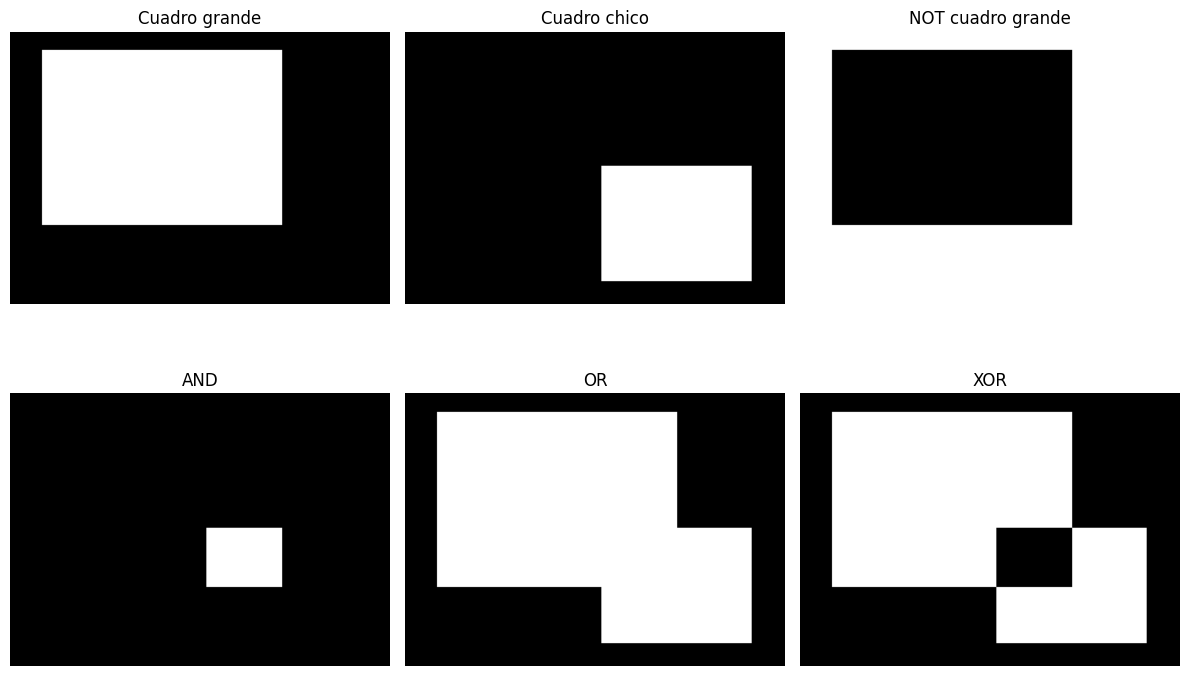

In [27]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

axes[0, 0].imshow(
    bin_grande,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0, 0].set_title("Cuadro grande")
axes[0, 0].axis("off")

axes[0, 1].imshow(
    bin_chica,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0, 1].set_title("Cuadro chico")
axes[0, 1].axis("off")

axes[0, 2].imshow(
    resultado_not_grande,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0, 2].set_title("NOT cuadro grande")
axes[0, 2].axis("off")

axes[1, 0].imshow(
    resultado_and,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1, 0].set_title("AND")
axes[1, 0].axis("off")

axes[1, 1].imshow(
    resultado_or,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1, 1].set_title("OR")
axes[1, 1].axis("off")

axes[1, 2].imshow(
    resultado_xor,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1, 2].set_title("XOR")
axes[1, 2].axis("off")

plt.tight_layout()

fig.savefig(
    "resultados/operaciones_logicas_pt6.png",
    dpi=150
)

plt.show()

### Conclusiones del punto 6 – Operaciones lógicas entre imágenes

En este punto se implementaron manualmente, mediante ciclos, las operaciones lógicas AND, OR, XOR y NOT sobre imágenes binarias.

Antes de aplicar las operaciones, las imágenes fueron binarizadas para asegurar que cada píxel tomara únicamente los valores 0 o 255, equivalentes a falso y verdadero respectivamente.

Los resultados obtenidos fueron:

- **AND:** conserva únicamente las regiones donde ambas imágenes presentan píxeles blancos.
- **OR:** genera la unión de las regiones blancas de ambas imágenes.
- **XOR:** conserva únicamente las regiones donde las imágenes son diferentes, eliminando la zona de intersección.
- **NOT:** invierte los valores de una imagen, convirtiendo negro en blanco y blanco en negro.

Las imágenes obtenidas coinciden con el comportamiento esperado de las tablas de verdad de cada operación lógica.

En conclusión, las operaciones lógicas permiten combinar, comparar o aislar regiones binarias de diferentes imágenes y son útiles en procesos posteriores como segmentación, creación de máscaras y análisis de objetos.

## Conclusión general del Taller 4

El desarrollo del taller permitió comprender la importancia de la vecindad y del procesamiento local en imágenes digitales.

Inicialmente se trabajó con la vecindad de 8 píxeles, comprobando que el análisis de los valores próximos a un píxel permite describir características locales de una región de la imagen.

Posteriormente, la ecualización local mostró cómo la media y la desviación estándar de una vecindad pueden utilizarse para adaptar el contraste de manera diferente en cada zona. La comparación entre la versión sin límites y la implementación con \(A_{\min}=0.5\) y \(A_{\max}=2.5\) permitió comprobar que limitar el factor de realce evita modificaciones excesivas y reduce la saturación.

Finalmente, las operaciones AND, OR, XOR y NOT demostraron cómo las imágenes binarias pueden tratarse mediante operaciones lógicas píxel a píxel para combinar, separar o invertir regiones.

En conjunto, el taller permitió relacionar tres ideas fundamentales del procesamiento digital de imágenes: **vecindad, procesamiento local y operaciones lógicas**, conceptos que posteriormente son utilizados en tareas como segmentación, detección de objetos, filtrado y análisis de regiones.